In [1]:
# ==========================================================
# 1. 라이브러리 호출
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve  # 이상탐지 성능 평가를 위한 ROC_AUC 계산에 활용

np.random.seed(42)        # 난수 고정을 위해 Numpy 시드 값을 설정
tf.random.set_seed(42)

In [6]:
# ==========================================================
# 2. 가상 센서 데이터 생성
# ==========================================================

n_normal = 5000      # 정상 데이터 샘플 수
n_anomaly = 500      # 이상 데이터 샘플 수
n_features = 4       # 센서 개수

# 정상 데이터 : 평균 0, 표준편차 1인 정규분포에서 값을 샘플링하여 센서 데이터 생성
normal_data = np.random.normal(loc=0.0, scale=1.0, size=(n_normal, n_features))

# 이상 데이터 : 평균을 크게 이동시키고, 분산을 키워서 비정상적인 패턴의 센서 데이터 생성
anomal_data = np.random.normal(loc=3.0, scale=1.5, size=(n_anomaly, n_features))

# 정상과 이상 데이터를 위아래로 이어 붙임
X = np.vstack([normal_data, anomaly_data])

# 정상은 0, 이상은 1로 레이블 벡터 생성
y = np.hstack([np.zeros(n_normal), np.ones(n_anomaly)])

In [7]:
anomal_data

array([[2.30644253, 4.302063  , 2.63024907, 3.03625977],
       [2.88236793, 1.66170097, 2.74309391, 2.31327411],
       [1.96228921, 1.41253653, 2.84909516, 3.92725515],
       ...,
       [0.45715649, 1.29452451, 3.16391551, 4.4214788 ],
       [5.20746405, 4.48763478, 5.32839737, 3.27309073],
       [2.0676181 , 4.77612955, 5.04525603, 4.39623459]], shape=(500, 4))

In [16]:
# ==========================================================
# 3. 학습/테스트 데이터 분리
# ==========================================================

# 전체 데이터에서 70%를 학습용으로 사용하고, 30% 테스트용으로 나누고, 레이블 비율을 유지
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 이상탐지 autoencoder는 보통 정상 데이터로만 학습하므로 정상 샘플만 필터링
X_train_normal = X_train[y_train == 0]  # 학습 데이터 중 레이블이 0(정상)인 데이터만 필터

In [23]:
# ==========================================================
# 4. 데이터 스케일링 (표준화)
# ==========================================================
scaler = StandardScaler()          # 평균 0, 분산 1로 맞추는 표준화 객체 생성
scaler.fit(X_train_normal)         # 정상 학습 데이터로 표준화 기준을 학습

X_train_normal_scaled = scaler.transform(X_train_normal) #학습용 정상 데이터를 표준화
X_test_scaled = scaler.transform(X_test)

In [24]:
# ==========================================================
# 5. Autoencoder 모델 정의
# ==========================================================

input_dim = n_features            # 입력 차원은 센서 개수와 동일하게 설정
encoding_dim = 2                  # 잠재공간(latent space) 2차원으로 설정해서 압축 진행

# 입력 레이어 정의, 입력 크기는 센서 개수와 동일하게 설정
input_layer = layers.Input(shape=(input_dim,), name='input')

# 인코더 부분 : 입력을 더 작은 차원으로 압축하는 레이어
encoded = layers.Dense(8, activation='relu', name='encoder_dense1')(input_layer)   # 8개의 뉴런으로 첫 번째 레이어를 만듬
encoded = layers.Dense(encoding_dim, activation='relu', name='encoder_dense2')(encoded)  # 2차원 잠재 표현으로 압축한다.

# 디코더 부분 : 압축된 표현을 다시 원래 차원으로 복원하는 레이어
decoded = layers.Dense(8, activation='relu', name='decoder_dense1')(encoded)       # 8개의 뉴런으로 복원을 하는 중간 레이어를 만듬
decoded = layers.Dense(input_dim, activation='linear', name='decoder_output')(decoded)  # 원래 입력 차원으로 복원하는 출력층

# 입력부터 출력까지를 연결해주는 autoencoder 모델 구성
autoencoder = models.Model(inputs=input_layer, outputs=decoded, name='autoencoder_model')

# 모델 구조를 출력해서 설계된 레이어를 확인할 수 있음
autoencoder.summary()

Model: "autoencoder_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                   │ (None, 4)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder_dense1 (Dense)               │ (None, 8)                   │              40 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder_dense2 (Dense)               │ (None, 2)                   │              18 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder_dense1 (Dense)               │ (None, 8)                   │              24 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder_output (Dense)               │ (None, 4)                   │              36 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 118 (472.00 B)

 Trainable params: 118 (472.00 B)

 Non-trainable params: 0 (0.00 B)

In [42]:
# ==========================================================
# 6. Autoencoder 컴파일
# ==========================================================

autoencoder.compile (
    optimizer='adam',      # 최적화 알고리즘은 adam 사용
    loss='mse'             # 인력과 복원된 출력의 차이를 제곱오차(MSE)로 계산
)
# --> 이상탐지의 경우 재구성 오차를 줄이는 방향으로 학습함

In [48]:
# ==========================================================
# 7. Autoencoder 학습
# ==========================================================

history = autoencoder.fit(
    X_train_normal_scaled,        # 입력과 타겟이 동일한 정상 데이터를 사용
    X_train_normal_scaled,        # 입력을 그래도 복원(decode)하도록 학습
    epochs=50,                   # 50번 반복 학습
    batch_size=64,               # 미니배치 크기 64
    validation_split=0.2,        # 학습데이터의 20% 검증
    verbose=1                   # 학습 진행상황을 로그로 출력
)

Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3676 - val_loss: 0.3794
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3673 - val_loss: 0.3790
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3671 - val_loss: 0.3789
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3669 - val_loss: 0.3784
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3667 - val_loss: 0.3782
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3664 - val_loss: 0.3777
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3661 - val_loss: 0.3776
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3658 - val_loss: 0.3772
Epoch 9/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3656 - val_loss: 0.3769
Epoch 10/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3653 - val_loss: 0.3767
Epoch 11/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3651 - val_loss: 0.3763
Epoch 12/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3648 - val_lo

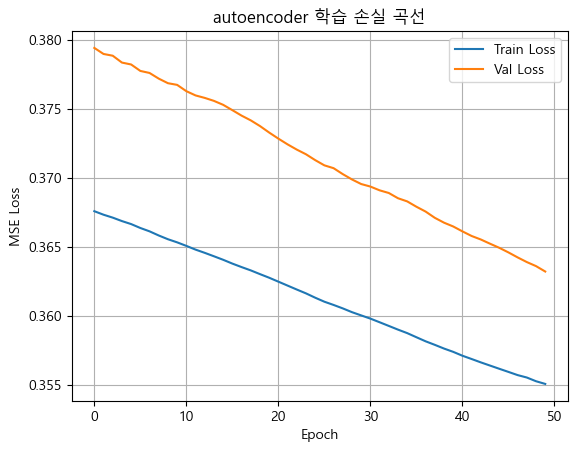

In [52]:
# 8. 학습과정 시각화 (loss)
# ============================

# 그래프 한글 폰트 설정
from matplotlib import font_manager, rc
plt.rcParams['font.family'] = 'Malgun Gothic'   # 한글 폰트 지정
plt.rcParams['axes.unicode_minus'] = False       #마이너스 부호 깨짐 방지

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('autoencoder 학습 손실 곡선')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

In [34]:
#========================================================

X_test_pred = autoencoder.predict(X_test_scaled)      #테스트 데이터를 autoencoder에 통과시켜서 복원값을 얻어옴
reconstruction_error = np.mean(np.square(X_test_scaled - X_test_pred), axis=1)
# 각 샘플에 대해서 (입력 - 복원값)^2를 계산하고, 특징 자원 방향으로 평균을 내서 재구성 오차를 구하는 결과

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [35]:
# ==========================================================
# 10. 이상 탐지 임계값(threshold) 설정
# ==========================================================

# 정상 학습 데이터의 재구성 오차 분포를 기반으로 임계값 설정
X_train_pred = autoencoder.predict(X_train_normal_scaled)   # 학습용 정상 데이터에서 복원값 구함

train_reconstruction_error = np.mean(
    np.square(X_train_normal_scaled - X_train_pred), axis=1
)   # 정상 학습 데이터의 재구성 오차를 계산

threshold = np.percentile(train_reconstruction_error, 95)   # 정상 오차의 90 퍼센타일을 임계값으로 설정

print("이상 탐지 임계값 (90%):", threshold)   # 결정된 임계값 출력 확인

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 766us/step
이상 탐지 임계값 (90%): 1.3884942314263256


재구성 오차 기반 ROC-AUC : 0.9955333333333334


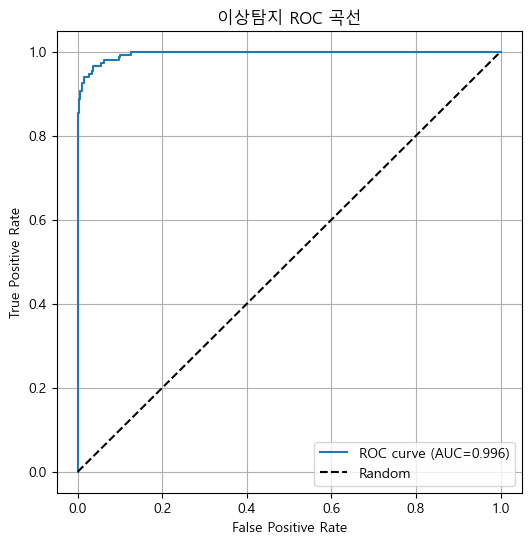

In [38]:
# ==========================================================
# 11. 이상 여부 예측 및 ROC-AUC 평가
# ==========================================================

# 재구성 오차가 임계값보다 크면 이상(1), 작으면 정상(0)으로 예측 레이블을 만듬
y_pred_anomaly = (reconstruction_error > threshold).astype(int)

# 재구성 오차를 점수로 사용해서 ROC-AUC를 계산해서 이상탐지 성능 측정
auc = roc_auc_score(y_test, reconstruction_error)
print("재구성 오차 기반 ROC-AUC :", auc)   # 계산된 AUC 값을 출력

fpr, tpr, _ = roc_curve(y_test, reconstruction_error)  # ROC 곡선을 그리기 위해 FPR, TPR 값을 계산

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC={auc:.3f})')   # FPR-TPR 곡선을 그리고 AUC를 표시
plt.plot([0, 1], [0, 1], 'k--', label='Random')          # 무작위 분류 기준선(대각선)을 점선으로 그리기

plt.xlabel('False Positive Rate')   # X축 라벨을 거짓양성률로 설정
plt.ylabel('True Positive Rate')    # Y축 라벨을 진양성률로 설정

plt.title('이상탐지 ROC 곡선')
plt.legend()
plt.grid(True)
plt.show()

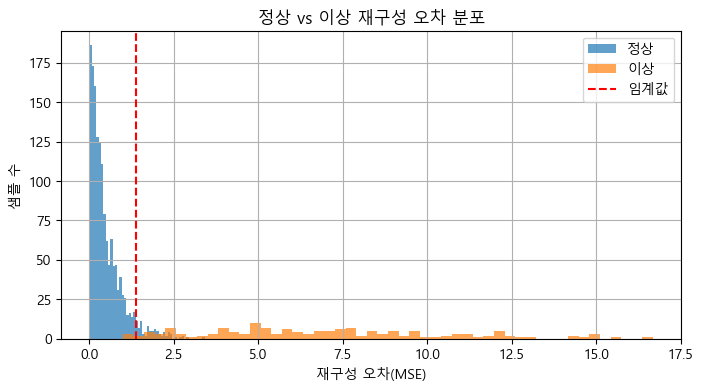

In [53]:
# ==========================================================
# 12. 재구성 오차 분포 시각화
# ==========================================================

plt.figure(figsize=(8, 4))

plt.hist(reconstruction_error[y_test == 0], bins=50, alpha=0.7, label='정상')   # 정상 샘플 오차 분포 그리기
plt.hist(reconstruction_error[y_test == 1], bins=50, alpha=0.7, label='이상')   # 이상 샘플 오차 분포 그리기

plt.axvline(threshold, color='red', linestyle='--', label='임계값')   # threshold 선 그리기

plt.title('정상 vs 이상 재구성 오차 분포')
plt.xlabel('재구성 오차(MSE)')
plt.ylabel('샘플 수')

plt.legend()
plt.grid(True)
plt.show()

# 도메인 Rule Base를 기반으로 